# Audio Analysis with Librosa and Pydub

This notebook demonstrates various audio processing and analysis techniques using Python libraries such as **librosa** and **pydub**. The workflow includes:

- Loading and visualizing audio waveforms
- Extracting audio features (MFCCs, pitch, tempo)
- Audio manipulation (trimming, volume adjustment)
- Spectral analysis (spectrograms, power spectrum)
- Advanced audio features (formants, timbre)
- Signal processing fundamentals (FFT, magnitude/power spectrum)

Librosa is a powerful Python library for audio and music analysis. It provides the building blocks necessary to create music information retrieval systems. Below is a simple example of how to use Librosa to load an audio file, visualize its waveform, and compute its spectrogram.

In [1]:
%pip install librosa pydub matplotlib scipy soundfile --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import librosa
import librosa.display
from pydub import AudioSegment
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal

/usr/local/python/3.12.1/lib/python3.12/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [3]:
# Load audio file (y = waveform array, sr = sampling rate)
y, sr = librosa.load("librosa_sample.mp3", sr=None)  # sr=None keeps original sample rate

In [4]:
y # waveform array

array([0.0000000e+00, 1.5758566e-11, 9.9567073e-12, ..., 2.2847325e-07,
       3.1726399e-06, 3.8299268e-06], shape=(677376,), dtype=float32)

In [5]:
sr # sampling rate

48000

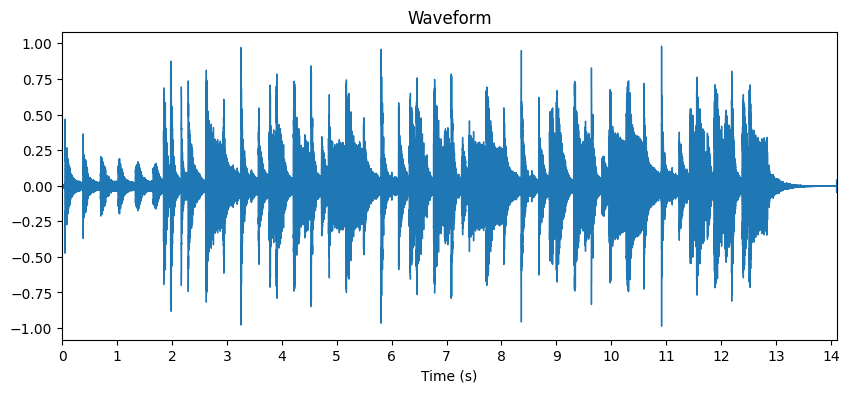

In [6]:
# Display waveform
# Set x-axis ticks at 1-second intervals
duration_sec = len(y) / sr
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
ax = plt.gca()
ax.set_xticks(np.arange(0, max(duration_sec, 1) + 1, 1))
ax.set_xlim(0, duration_sec)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.show()

In [7]:
# Get duration
duration = librosa.get_duration(y=y, sr=sr)
print(f"Duration: {duration:.2f} seconds")

Duration: 14.11 seconds


The code snippet n_mfcc=13 is a parameter within the librosa.feature.mfcc() function. It specifies the number of Mel-Frequency Cepstral Coefficients (MFCCs) to extract from the audio. MFCCs are a representation of the short-term power spectrum of a sound. The number of coefficients (n_mfcc) determines the dimensionality of this representation. In the code, n_mfcc=13 is used, meaning 13 MFCCs are calculated for each frame of the audio. This is a common number of coefficients used in various audio analysis tasks.

In [8]:
# Extract MFCCs (Mel-Frequency Cepstral Coefficients)
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print("MFCC shape:", mfccs.shape)

MFCC shape: (13, 1324)


In [9]:
mfccs

array([[-536.15436   , -513.3065    , -434.5153    , ..., -439.4433    ,
        -451.26093   , -530.54675   ],
       [   0.        ,    9.793169  ,   39.477566  , ...,   -0.88141227,
           4.851226  ,    1.4750675 ],
       [   0.        ,  -20.023605  ,  -58.240578  , ...,  -74.93646   ,
         -66.407776  ,   -6.6742525 ],
       ...,
       [   0.        ,    2.77353   ,    4.979423  , ...,    8.137921  ,
          10.6921425 ,    2.3676193 ],
       [   0.        ,   -1.7886996 ,    2.8610106 , ...,    5.5376043 ,
           7.114663  ,   -2.569501  ],
       [   0.        ,    1.70069   ,   16.52326   , ...,    3.6793518 ,
           1.4256184 ,   -3.196941  ]], shape=(13, 1324), dtype=float32)

In [10]:
import soundfile as sf
from IPython.display import Audio

In [11]:
# First load with librosa and save as WAV
y, sr = librosa.load("librosa_sample.mp3", sr=None)
sf.write("librosa_sample.wav", y, sr)

# Then load the WAV with pydub
audio = AudioSegment.from_file("librosa_sample.wav")

In [12]:
audio.export("audio_sample.wav", format="wav")
# Display audio player
Audio("audio_sample.wav")

In [13]:
# Trim first 5 seconds
trimmed = audio[5000:]  # from 5 sec to end

In [14]:
# Change volume (+10 dB)
louder = trimmed + 10

In [15]:
louder.export("louder_audio.wav", format="wav")
# Display audio player
Audio("louder_audio.wav")

In [16]:
print("Audio manipulation complete")
print(f"Louder audio duration: {len(louder)} ms at {louder.frame_rate} Hz with {louder.frame_count()} samples")

Audio manipulation complete
Louder audio duration: 9112 ms at 48000 Hz with 437376.0 samples


In [ ]:
# Trim down to segments in between
trimmed1 = audio[3200:5800]
trimmed1.export("temp.wav", format="wav")

trimmed2 = audio[3200:5800]
trimmed2.export("temp.wav", format="wav")


# Play Audio
Audio("temp.wav")

In [18]:
print("Audio manipulation complete")
print(f"Trimmed audio duration: {trimmed.duration_seconds} seconds with {trimmed.frame_count()} samples")

Audio manipulation complete
Trimmed audio duration: 4.0 seconds with 192000.0 samples


In [19]:
# Speed up the trimmed audio
speeded = trimmed.speedup(playback_speed=2).export("speeded_audio.wav", format="wav")
# Play Audio
Audio("speeded_audio.wav")

In [20]:
# Inserting the speeded audio into original audio from where it was trimmed at 4th second and 8th second
combined = audio[:4000] + AudioSegment.from_file("speeded_audio.wav") + audio[5000:7000] + AudioSegment.from_file("speeded_audio.wav") + audio[8000:]
combined.export("combined_audio.wav", format="wav")
# Play Audio
Audio("combined_audio.wav")

In [21]:
# Load the converted WAV file for further analysis
y, sr = librosa.load("librosa_sample.wav", sr=None)

In [22]:
y.shape

(677376,)

In [23]:
sr

48000

In [24]:
tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

In [25]:
print(f"Estimated Tempo: {tempo[0]:.2f} BPM")
# tempo

Estimated Tempo: 93.75 BPM


In [26]:
_

array([   5,   66,  125,  174,  245,  306,  365,  425,  485,  545,  605,
        665,  724,  784,  844,  904,  964, 1024, 1083, 1143])

## Using Example

In [27]:
librosa.util.list_examples()

AVAILABLE EXAMPLES
--------------------------------------------------------------------
brahms    	Brahms - Hungarian Dance #5
choice    	Admiral Bob - Choice (drum+bass)
fishin    	Karissa Hobbs - Let's Go Fishin'
humpback  	Glacier Bay 60-second clip humpback whale song November 2020
libri1    	Ashiel Mystery - A Detective Story, chapter 2, narrated by Garth Comira
libri2    	The Age of Chivalry / Chapter 18: Perceval / Read by Anders Lankford
libri3    	Sense and Sensibility / Chapter 18 / Jane Austen / Read by Heather Barnett
nutcracker	Tchaikovsky - Dance of the Sugar Plum Fairy
pistachio 	The Piano Lady - Pistachio Ice Cream Ragtime
robin     	Bird Whistling, Robin, Single, 13.wav / InspectorJ
sweetwaltz	Setuniman - Sweet Waltz
trumpet   	Mihai Sorohan - Trumpet loop
vibeace   	Kevin MacLeod - Vibe Ace


In [28]:
y, sr = librosa.load(librosa.example('trumpet'))

In [29]:
y.shape

(117601,)

In [30]:
sr

22050

In [31]:
# Compute spectrogram
S = librosa.stft(y)

In [32]:
S.shape

(1025, 230)

In [33]:
S_db = librosa.amplitude_to_db(abs(S))

In [34]:
S_db.shape

(1025, 230)

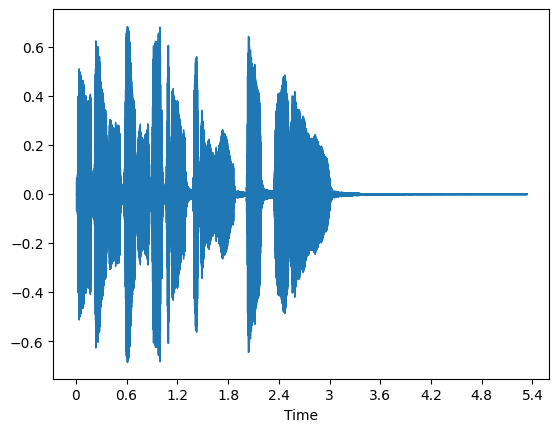

In [35]:
librosa.display.waveshow(y, sr=sr)

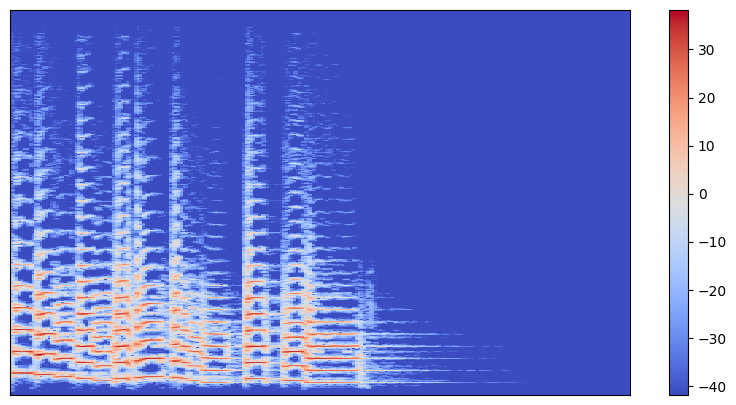

In [36]:
# Display
plt.figure(figsize=(10, 5))
librosa.display.specshow(S_db, sr=sr)
plt.colorbar()

In [37]:
# librosa.display.waveshow(y, sr=sr)

### Pitch extraction (fundamental frequency)

In [38]:
f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=50, fmax=500, sr=sr)

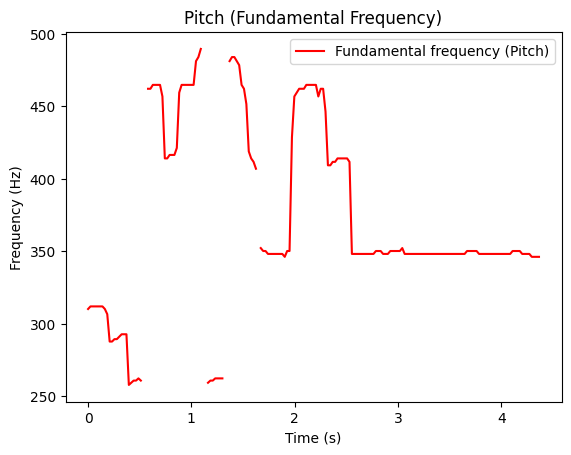

In [39]:
times = librosa.times_like(f0, sr=sr)
plt.plot(times, f0, label='Fundamental frequency (Pitch)', color='r')
plt.title("Pitch (Fundamental Frequency)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.legend()

### Timbre or Quality of Sound (MFCCs)

In [40]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

Text(0.5, 1.0, 'MFCCs (Timbre features)')

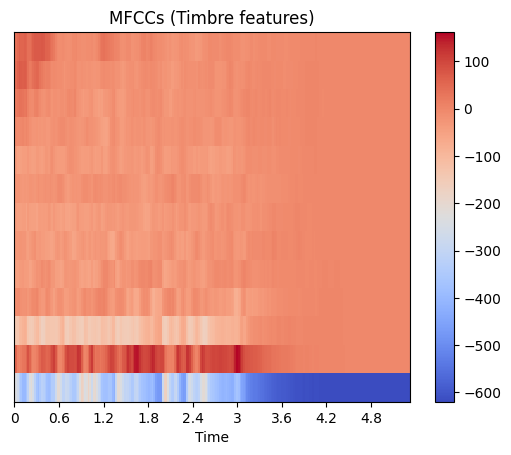

In [41]:
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar()
plt.title("MFCCs (Timbre features)")

### Formants (using LPC approximation)

In [42]:
def estimate_formants(frame, sr, order=12):
    # Apply a Hamming window
    frame = frame * np.hamming(len(frame))
    # LPC coefficients
    A = librosa.lpc(frame, order=order)
    # Roots of LPC polynomial
    rts = np.roots(A)
    rts = [r for r in rts if np.imag(r) >= 0.01]
    angz = np.arctan2(np.imag(rts), np.real(rts))
    freqs = sorted(angz * (sr / (2*np.pi)))
    return freqs[:3]  # First 3 formants


In [43]:
# Take a short frame (~30 ms) from the middle of audio
frame_size = int(0.03 * sr)
midpoint = len(y)//2
frame = y[midpoint:midpoint+frame_size]
formants = estimate_formants(frame, sr)

In [44]:
midpoint, frame.shape

(58800, (661,))

In [45]:
y.shape

(117601,)

In [46]:
formants

[np.float64(790.4430596952311),
 np.float64(1371.0723219287945),
 np.float64(2214.250892424988)]

# Power Spectrum

In [47]:
# Take a short segment for clarity
y = y[:sr*2]  # 2 seconds

In [48]:
# Compute FFT
N = len(y)
Y = np.fft.fft(y)
frequencies = np.fft.fftfreq(N, 1/sr)

In [49]:
# Compute Power Spectrum (only positive frequencies)
power_spectrum = np.abs(Y)**2
positive_freqs = frequencies[:N//2]
positive_power = power_spectrum[:N//2]

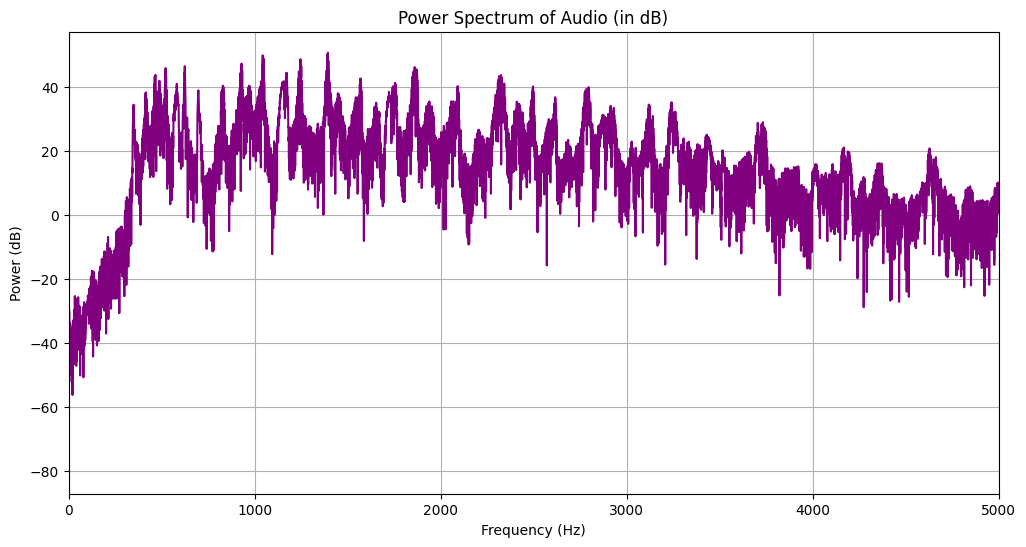

In [50]:

plt.figure(figsize=(12, 6))
plt.plot(positive_freqs, 10*np.log10(positive_power), color='purple')
plt.title("Power Spectrum of Audio (in dB)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.xlim(0, 5000)  # limit for visibility
plt.grid(True)
plt.show()


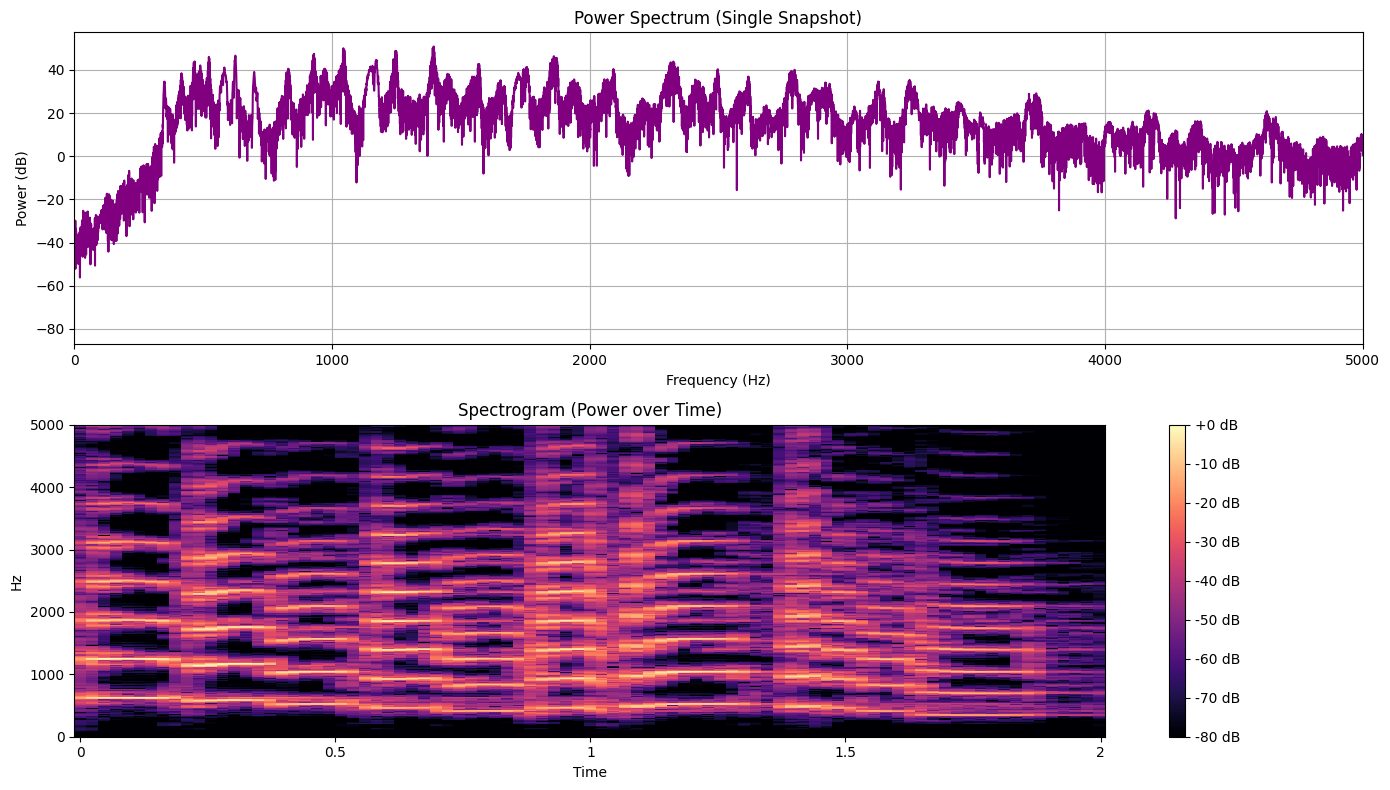

In [51]:
# Compare Power Spectrum vs Spectrogram

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Load sample audio (trumpet)
y, sr = librosa.load(librosa.ex('trumpet'))

# Use first 2 seconds
y = y[:sr*2]

# ----- Power Spectrum (single snapshot) -----
N = len(y)
Y = np.fft.fft(y)
frequencies = np.fft.fftfreq(N, 1/sr)
power_spectrum = np.abs(Y)**2
positive_freqs = frequencies[:N//2]
positive_power = power_spectrum[:N//2]

# ----- Spectrogram (over time) -----
S = np.abs(librosa.stft(y))**2   # Power spectrogram
S_db = librosa.power_to_db(S, ref=np.max)

# ----- Plot both -----
plt.figure(figsize=(14, 8))

# Power Spectrum
plt.subplot(2, 1, 1)
plt.plot(positive_freqs, 10*np.log10(positive_power), color='purple')
plt.title("Power Spectrum (Single Snapshot)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.xlim(0, 5000)
plt.grid(True)

# Spectrogram
plt.subplot(2, 1, 2)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (Power over Time)")
plt.ylim(0, 5000)

plt.tight_layout()
plt.show()


### Create a simple test signal: sum of two sine waves + a bit of noise

In [52]:

sr = 8000                   # sampling rate (Hz)
T = 1.0                     # duration (seconds)
t = np.linspace(0, T, int(sr*T), endpoint=False)
f1, f2 = 440, 1000          # two tones at 440 Hz and 1000 Hz
x = 0.8*np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t) + 0.05*np.random.randn(len(t))

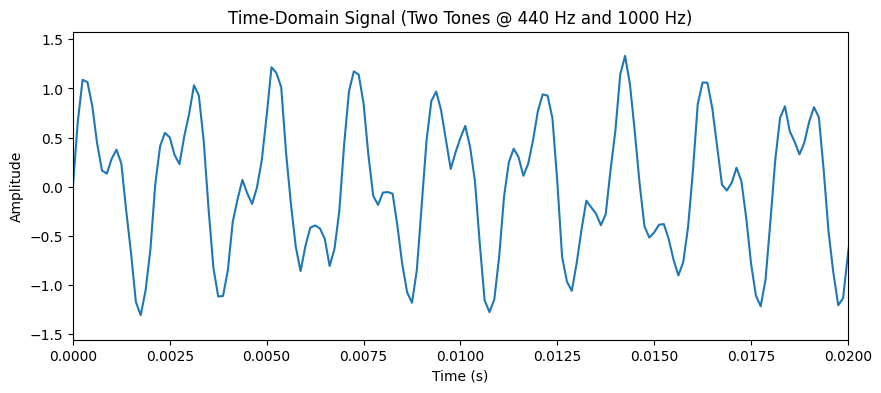

In [53]:
plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.title("Time-Domain Signal (Two Tones @ 440 Hz and 1000 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 0.02)  # zoom into first 20 ms for clarity
plt.show()

### Magnitude Spectrum

In [54]:
N = len(x)
X = np.fft.rfft(x)                   # one-sided FFT (real input optimization)
freqs = np.fft.rfftfreq(N, d=1/sr)   # corresponding frequencies

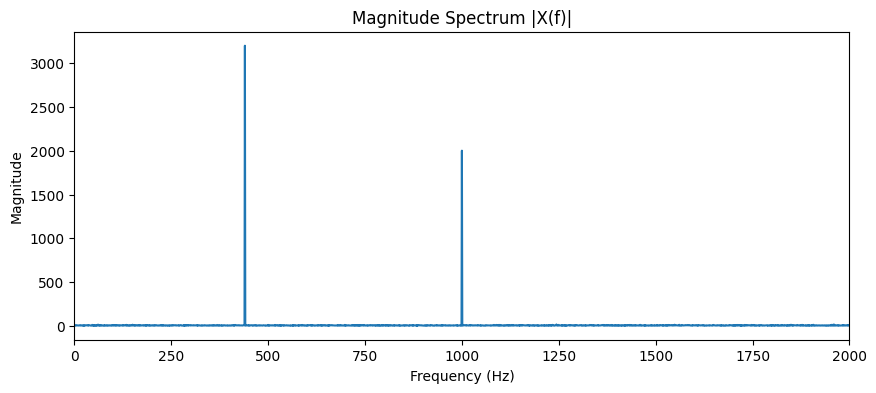

In [55]:
mag = np.abs(X)

plt.figure(figsize=(10, 4))
plt.plot(freqs, mag)
plt.title("Magnitude Spectrum |X(f)|")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)  # focus around our tones
plt.show()

### Power Spectrum |X(f)|^2 (in linear scale)

In [56]:
mag = np.abs(X)

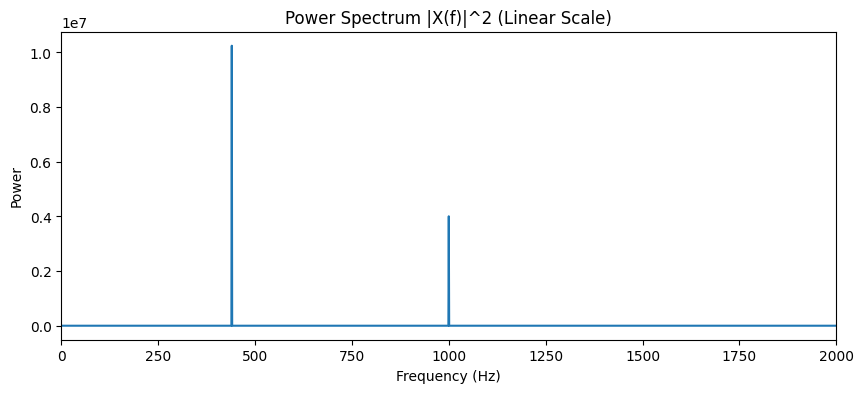

In [57]:
power = mag**2

plt.figure(figsize=(10, 4))
plt.plot(freqs, power)
plt.title("Power Spectrum |X(f)|^2 (Linear Scale)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.xlim(0, 2000)
plt.show()

### Power Spectrum in dB

In [58]:
power = mag**2

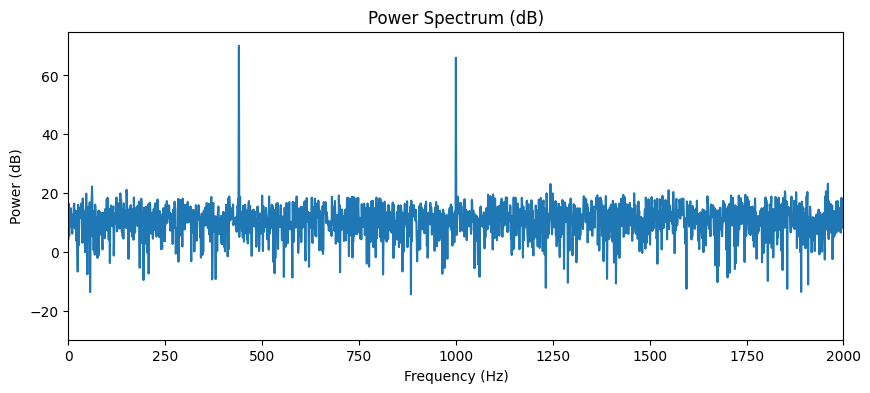

In [59]:
eps = 1e-12
power_db = 10*np.log10(power + eps)
plt.figure(figsize=(10, 4))
plt.plot(freqs, power_db)
plt.title("Power Spectrum (dB)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.xlim(0, 2000)
plt.show()